# CIF in ten minutes

Certified Interventional Fidelity (CIF) adds anytime-valid confidence sequences to interventional interpretability metrics such as interchange intervention accuracy, activation patching, causal scrubbing, circuit completeness. This notebook tours the library on synthetic data: everything runs in seconds on CPU. The second notebook, `02_reproducing_the_paper.ipynb`, loads the saved experiment results and rebuilds the paper's tables and figures.

The whole user-facing API is one tracker object per estimand: call `update(z, w)` per intervention, query `lcb_fidelity` / `ucb_fidelity` whenever you like, stop whenever you like.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "code"))

import numpy as np
import matplotlib.pyplot as plt

from cif import (
    CIFTracker,
    BettingCSTracker,
    PairedCIFTracker,
    PairedBettingCSTracker,
    cs_radius,
)

rng = np.random.default_rng(0)
%matplotlib inline

## 1. The estimand

Every metric CIF covers reduces to a bounded mean. Each intervention trial produces a discrepancy $Z \in [0,1]$ (for interchange interventions, $Z$ is the 0/1 disagreement indicator between the model and its abstraction). The interventional risk is $R = \mathbb{E}[Z]$ and fidelity is $F = 1 - R$.

Below we simulate trials from a high-fidelity abstraction: the model and abstraction disagree on 3% of sampled interventions, so $R = 0.03$ and $F = 0.97$.

In [2]:
R_TRUE = 0.03
F_TRUE = 1 - R_TRUE

def draw_trials(n, r=R_TRUE, rng=rng):
    return (rng.random(n) < r).astype(float)

z = draw_trials(5)
z

array([0., 0., 0., 1., 0.])

## 2. Hoeffding vs betting confidence sequences

`CIFTracker` maintains the union-bound Hoeffding confidence sequence (CS): its width depends only on $n$. `BettingCSTracker` maintains the ONS betting CS, which adapts to the empirical variance of the stream; for a low-variance stream like this one it is much tighter at the same $n$. Both are valid *simultaneously for all $n$*, so you can monitor and stop at will.

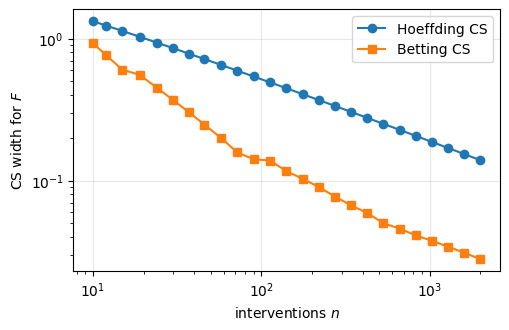

After n=2000:
  Hoeffding: F in [0.894, 1.000]
  Betting:   F in [0.948, 0.976]   (true F = 0.97)


In [3]:
n_total = 2000
checkpoints = np.unique(np.geomspace(10, n_total, 25).astype(int))

hoeff = CIFTracker(delta=0.05)
bet = BettingCSTracker(delta=0.05)

widths_h, widths_b = [], []
stream = draw_trials(n_total)
k = 0
for cp in checkpoints:
    while k < cp:
        hoeff.update(stream[k])
        bet.update(stream[k])
        k += 1
    widths_h.append(2 * hoeff.radius)
    widths_b.append(2 * bet.radius)

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.loglog(checkpoints, widths_h, "o-", label="Hoeffding CS")
ax.loglog(checkpoints, widths_b, "s-", label="Betting CS")
ax.set_xlabel("interventions $n$")
ax.set_ylabel("CS width for $F$")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"After n={n_total}:")
print(f"  Hoeffding: F in [{hoeff.lcb_fidelity:.3f}, {hoeff.ucb_fidelity:.3f}]")
print(f"  Betting:   F in [{bet.lcb_fidelity:.3f}, {bet.ucb_fidelity:.3f}]   (true F = {F_TRUE})")

## 3. Certification: stop at the first crossing

To certify $F \ge F_0$, run until the lower confidence bound crosses $F_0$. Because the CS is anytime-valid, stopping at the first crossing does not break the coverage guarantee. The stopping-time gap between the two constructions is the paper's central practical point.

In [4]:
def betting_stopping_time(f0, r=R_TRUE, check_every=20, n_max=20_000, seed=1):
    rng_local = np.random.default_rng(seed)
    tr = BettingCSTracker(delta=0.05)
    n = 0
    while n < n_max:
        for zt in (rng_local.random(check_every) < r).astype(float):
            tr.update(zt)
        n += check_every
        if tr.is_certified(f0):
            return n
    return None

def hoeffding_stopping_time(f0, r=R_TRUE, n_max=50_000, seed=1):
    rng_local = np.random.default_rng(seed)
    fails = 0
    for n in range(1, n_max + 1):
        fails += rng_local.random() < r
        lcb_f = 1 - (fails / n + cs_radius(n, 0.05))
        if lcb_f >= f0:
            return n
    return None

print(f"{'threshold':>10} {'Hoeffding n':>12} {'Betting n':>10}")
for f0 in [0.90, 0.95]:
    nh = hoeffding_stopping_time(f0)
    nb_ = betting_stopping_time(f0)
    print(f"{f0:>10} {str(nh):>12} {str(nb_):>10}")

 threshold  Hoeffding n  Betting n
       0.9         1857        160


      0.95        27447        700


On the paper's MNIST and GPT-2 experiments this gap is a factor of 10 to 30: configurations that need thousands of forward passes under Hoeffding certify in tens to hundreds under betting.

## 4. Peeking is safe

The CS guarantee is time-uniform: $\Pr(\forall n: R \in C_n) \ge 1-\delta$. You can check after each trial and act on what you see. The cell below monitors the Hoeffding CS at every step across 400 replications and counts how often the truth ever escapes the sequence; the failure rate stays below $\delta = 0.05$ even under maximal peeking. (Experiment E4 in the paper runs the full version of this check, including the betting CS and adversarial stopping rules.)

In [5]:
def ever_misses(seed, n=1500, r=R_TRUE, delta=0.05):
    rng_local = np.random.default_rng(seed)
    zs = (rng_local.random(n) < r).astype(float)
    cum = np.cumsum(zs)
    ns = np.arange(1, n + 1)
    rad = np.array([cs_radius(int(t), delta) for t in ns])
    r_hat = cum / ns
    return bool(np.any(np.abs(r_hat - r) > rad))

misses = sum(ever_misses(s) for s in range(400))
print(f"time-uniform miss rate over 400 runs: {misses / 400:.3f}  (guarantee: <= 0.05)")

time-uniform miss rate over 400 runs: 0.000  (guarantee: <= 0.05)


## 5. Adaptive stress testing with bounded weights

Suppose you want to hunt for failures instead of sampling interventions i.i.d. from the target distribution $\Pi$. CIF makes this safe with a bounded-mixture proposal: sample from $q = (1-\alpha)\Pi + \alpha\,\tilde q$, where $\tilde q$ concentrates wherever you suspect failures. The importance weight $w = \Pi(I)/q(I)$ is then bounded by $W_{\max} = 1/(1-\alpha)$, and the trackers accept weighted updates.

The demo below has two strata: a small failure-prone region (10% of $\Pi$'s mass, 25% disagreement) and a benign region (1% disagreement). The stress proposal oversamples the failure-prone region five-fold. The weighted estimate stays centered on the true $R$; the unweighted average of the same stream is badly biased.

In [6]:
alpha = 0.3
p_bad_pi = 0.10
r_bad, r_good = 0.25, 0.01
R_strat = p_bad_pi * r_bad + (1 - p_bad_pi) * r_good

p_bad_q = (1 - alpha) * p_bad_pi + alpha * 0.5
w_bad = p_bad_pi / p_bad_q
w_good = (1 - p_bad_pi) / (1 - p_bad_q)
W_max = 1 / (1 - alpha)

tr = CIFTracker(delta=0.05, W_max=W_max)
naive = []
rng_local = np.random.default_rng(7)
for _ in range(4000):
    bad = rng_local.random() < p_bad_q
    zt = float(rng_local.random() < (r_bad if bad else r_good))
    tr.update(zt, w=(w_bad if bad else w_good))
    naive.append(zt)

print(f"true R                 : {R_strat:.4f}")
print(f"weighted estimate      : {tr.r_hat:.4f}")
print(f"unweighted (biased)    : {np.mean(naive):.4f}")
print(f"W_max = 1/(1-alpha)    : {W_max:.2f}")

true R                 : 0.0340
weighted estimate      : 0.0320
unweighted (biased)    : 0.0605
W_max = 1/(1-alpha)    : 1.43


One caution from the paper's matched comparison (Section 4.3 and Appendix E there; last section of notebook 02 here): a failure-concentrating proposal tightens *upper* bounds on $R$ and loosens *lower* bounds. Use adaptive sampling to find counterexamples; use i.i.d. sampling with the betting CS to certify.

## 6. Comparing two abstractions with a paired test

Evaluating two abstractions on the *same* sampled interventions reduces variance. The paired trackers consume $(z_1, z_2)$ pairs and maintain a CS for $\mu_\Delta = R^{(1)} - R^{(2)}$; a difference is significant once the CS excludes zero. With a small true gap, the paired Hoeffding CS (range 2) is too wide to detect it while the betting CS resolves it, matching the qualitative reversal the paper reports on MNIST.

In [7]:
mu_gap = 0.03
n_pairs = 10_000
rng_local = np.random.default_rng(3)

ph = PairedCIFTracker(delta=0.05)
pb = PairedBettingCSTracker(delta=0.05)
for _ in range(n_pairs):
    base = rng_local.random()
    z1 = float(base < 0.10 + mu_gap)
    z2 = float(base < 0.10)
    ph.update(z1, z2)
    pb.update(z1, z2)

print(f"true gap mu = {mu_gap}")
print(f"paired Hoeffding: mu_hat={ph.mu_hat:+.4f}, radius={ph.radius:.4f}, significant={ph.significant}")
print(f"paired betting:   mu_hat={pb.mu_hat:+.4f}, radius={pb.radius:.4f}, significant={pb.significant}")

true gap mu = 0.03
paired Hoeffding: mu_hat=+0.0280, radius=0.0672, significant=False


paired betting:   mu_hat=+0.0280, radius=0.0059, significant=True


## Where to go next

- `02_reproducing_the_paper.ipynb` rebuilds every table and figure of the paper from the saved results in `results/`.
- `code/e1_certified_iia.py` ... `code/e4_coverage.py` regenerate those results from scratch (`code/run_all.py` runs all four); `code/adaptive_study*.py` regenerate the adaptive-sampling study.
- The paper: Asiaee, *Certified Interventional Fidelity: Anytime-Valid, Adaptive Evaluation of Causal Claims in Mechanistic Interpretability*, UAI 2026.